# Previsão de valor de despesas em diárias e passagens (SCDP) com regressão

## Introdução a Machine Learning

* **Renê Estevam**
* **Rodrigo Costa** 
* **Liandro Silva** 

Este relatório segue a estrutura do **template da disciplina** (relatório preliminar – Fase 1), adaptada ao contexto do **SCDP** (Sistema de Custos de Diárias e Passagens) seguindo um modelo supervisionado de regressão para previsão do valor da despesa total.

---

## 1. Descrição da Base de Dados

* ### **Fonte dos dados:**  
  Base obtida em **dados abertos do governo federal**, via Portal da Transparência e conjunto *Viagens a Serviço do Governo Federal (SCDP)* em [dados.gov.br](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp). O arquivo utilizado é o CSV **base_rene_estevam_deckers.csv**, contendo registros de diárias e passagens dos **últimos 2 anos** da administração pública federal (Poder Executivo).

* ### **Contextualização:**  
  Cada **linha** representa um **trecho de viagem** ou um lançamento de diária: está vinculada a um servidor, a um órgão (e unidade gestora), às datas de início e término da viagem, ao **motivo** oficial, aos valores em reais (valor total, valor de diárias, valor de passagem) e ao **meio de transporte** quando há deslocamento. Pode haver **múltiplas linhas por viagem** (vários trechos ou lançamentos separados de diária e passagem). A base permite analisar padrões de gastos por órgão, motivo, meio de transporte e período, com relevância para **transparência**, **controle de custos** e **sustentabilidade** (redução de viagens e preferência por meios menos poluentes).

* ### **Enquadramento institucional — o que são viagens a serviço:**  
  Na **Administração Pública Federal Direta, fundações e autarquias**, viagens a serviço são **afastamentos** de servidores, militares, empregados públicos e colaboradores eventuais, em caráter **eventual ou transitório**, no território **nacional ou exterior**, período em que fazem jus a **passagens e diárias**. Esses valores **indenizam despesas extraordinárias** com pousada, alimentação e locomoção urbana, conforme a **Lei nº 8.112, de 1990**. Assim, **Valor total**, **Valor diárias** e **Valor passagem** referem-se a **custos de viagens institucionais**, não a gastos genéricos do órgão.

* ### **Como diárias e passagens entram nos registros (SCDP):**  
  O CSV traz **lançamentos** sujeitos a regras de sistema e de pagamento, e não apenas "a viagem" como fenômeno isolado:
  - Em geral há **data de início da viagem** na linha, mas os **valores monetários** podem corresponder a **outro momento** (pagamento ou registro administrativo).
  - **Viagens sigilosas:** em dados públicos, informações podem surgir **somente após o encerramento** do período de sigilo.
  - **Diárias:** costumam refletir situações em que houve **efetivação do pagamento** da parcela no **sistema financeiro** do governo.
  - **Passagens:** costumam aparecer em função do **registro da emissão** no **SCDP**.  
  Na **regressão**, o modelo só observa o que está na tabela: agregações por mês ou interpretações temporais devem considerar que o **alvo** pode estar mais ligado ao **fluxo de pagamento/registro** do que exclusivamente ao calendário de início da viagem.

* ### **SIAFI e outras fontes — contexto (não faz parte do escopo deste arquivo):**  
  O **SIAFI** (Sistema Integrado de Administração Financeira do Governo Federal) tem **lógica própria** de registro; há **órgãos que não utilizam o SCDP**. Em viagens **sigilosas**, despesas podem ser pagas/registradas no SIAFI enquanto, em bases públicas ligadas ao SCDP/transparência, a **mesma informação** pode só constar **depois** do fim do sigilo. **Este relatório** utiliza **apenas** o CSV dos **dados abertos** do conjunto SCDP; qualquer comparação futura com SIAFI exigiria critérios alinhados (datas, órgãos, definições de diária/passagem).

* ### **Implicações para as análises deste notebook:**  
  - **Lei 8.112/1990** dá significado normativo às variáveis de valor (boa base para interpretar o **target**).
  - **Datas** na base vs. momento de pagamento/registro → possível **desalinhamento temporal**; interpretar gráficos e uso de datas como *features* com cuidado.
  - **Sigilo** pode atrasar a presença de algumas linhas em bases públicas (relevante para leituras longitudinais).
  - O **Valor total** (e afins) pode refletir **eventos administrativos**, não só características "físicas" da viagem.
  - **Escopo explícito:** arquivo exportado **dados.gov.br (SCDP)**; não extrapolar totais para outros sistemas sem harmonização.

* ### **Objetivo da utilização:**  
  Analisar padrões de gastos e preparar a **modelagem de regressão** para **prever o valor da despesa** (valor total do registro, ou valor de diárias/passagens), com vistas a orçamento, metas de redução de custos e apoio à auditoria.

* ### **Problema de pesquisa:**  
  *Qual o valor total da despesa a partir de características da viagem?*  
  Tipo de aprendizado: **supervisionado — Regressão**.

* ### **O que vai prever?**  
  **Variável alvo (target):** **Valor total** (em R$), representando o custo total do registro (diárias + passagens).

---

## 2. Dicionário de Dados

O dicionário de dados deve ser entregue **em arquivo separado (Excel)**.

O dicionário de dados foi gerado conforme o template (arquivo separado).  
- **Arquivo Excel (entrega):** `dicionario_rene_estevam_deckers.xlsx` — contém as **23 variáveis** da base, com colunas: ordem (#), Variável, Nome Descritivo, Tipo de Dado, Unidade de Medida, Domínio / Categoria, Descrição / Significado, Observações.  
- **Conteúdo:** para cada variável: tipo (numérico/categórico/data/Texto), unidade de medida e significado.

A base possui **23 variáveis** conforme abaixo:

| # | Variável | Tipo de Dado |
|---|----------|--------------|
| 1 | Código órgão superior | Numérico (inteiro) |
| 2 | Nome órgão superior | Categórico (nominal) |
| 3 | Código órgão | Numérico (inteiro) |
| 4 | Nome órgão | Categórico (nominal) |
| 5 | Código unidade gestora | Numérico (inteiro) |
| 6 | Nome unidade gestora | Categórico (nominal) |
| 7 | Nome servidor | Texto |
| 8 | Cargo | Categórico (nominal) |
| 9 | Data início viagem | Data |
| 10 | Data término viagem | Data |
| 11 | Motivo | Texto |
| 12 | Valor total | Numérico (contínuo) |
| 13 | Início trecho | Data |
| 14 | Término trecho | Data |
| 15 | Município origem | Categórico (nominal) |
| 16 | UF origem | Categórico (nominal) |
| 17 | Município destino | Categórico (nominal) |
| 18 | UF destino | Categórico (nominal) |
| 19 | Número diárias | Numérico (contínuo) |
| 20 | Valor diárias | Numérico (contínuo) |
| 21 | Meio de transporte | Categórico (nominal) |
| 22 | Categoria passagem | Categórico (nominal) |
| 23 | Valor passagem | Numérico (contínuo) |

---

## 3. Análises Descritivas Iniciais

### 3.1 Medidas de Posição e Dispersão

Objetivo: obter **tabelas e resumos estatísticos** para as variáveis numéricas principais, incluindo:

- **Posição:** média, mediana, mínimo, máximo, quartis (Q1, Q3).  
- **Dispersão:** desvio-padrão e **coeficiente de variação (CV%)** — útil para comparar variabilidade entre variáveis com escalas diferentes (ex.: Valor total em R$ vs. Número diárias em quantidade).

**O que são quartis (Q1, Q3)?** Os **quartis** dividem os dados ordenados em quatro partes iguais (cada uma com cerca de 25% das observações). **Q1 (primeiro quartil)** é o valor abaixo do qual está 25% dos dados — ou seja, 25% das despesas são *menores ou iguais* a Q1. **Q3 (terceiro quartil)** é o valor abaixo do qual está 75% dos dados — 75% das despesas são *menores ou iguais* a Q3. A **mediana** equivale ao segundo quartil (Q2): 50% dos dados ficam abaixo dela. Entre Q1 e Q3 fica a **metade central** dos valores; a diferença Q3 − Q1 é a **amplitude interquartílica**, uma medida de dispersão que não é tão sensível a outliers quanto o desvio-padrão.

As células abaixo (1) carregam o CSV, removem duplicatas e **convertem para numérico** as colunas que vêm com vírgula decimal (Valor total, Valor diárias, Valor passagem, Número diárias); (2) produzem a tabela de resumo para essas quatro variáveis; **(2b)** logo depois, um **complemento em texto e código** explica por que **Valor passagem** pode ter mediana e quartis em zero e mínimo negativo, e mostra percentuais de zeros/negativos e estatísticas **somente onde passagem > 0**; (3) na subseção **3.1.1**, quantificam **valores ausentes** por coluna; (4) na subseção **3.1.2**, analisam **correlação** com o target (Valor total). Na interpretação, observe: **assimetria** (média vs. mediana), **magnitude do CV** (alta variabilidade pode indicar outliers ou heterogeneidade) e **escala** dos valores (mín/máx) para planejar eventual transformação (ex.: log) na modelagem.

---

In [1]:
import pandas as pd  # tabelas / CSV
import numpy as np  # NaN, estatísticas
import matplotlib.pyplot as plt  # gráficos (seção 3.2)
import seaborn as sns  # estilo e heatmap

# UTF-8 padrão do portal; low_memory=False evita aviso de tipo misto ao ler o CSV em pedaços
df = pd.read_csv('base_rene_estevam_deckers.csv', low_memory=False, encoding='utf-8')  # cópia local do mesmo conjunto SCDP; só o nome do ficheiro muda
df = df.drop_duplicates()  # há linhas repetidas na base aberta — tirei para não distorcer médias e contagens

# Nomes de coluna podem mudar levemente entre exportações (acento, "diarias" sem til, etc.)
def acha_col(df, *nomes):  # tenta match exato; depois "parecido" e remove hífen invisível U+00AD se aparecer
    for n in nomes:
        if n in df.columns:
            return n  # achou o nome literal
    for c in df.columns:
        if any(n in c for n in nomes) or c.replace('\u00ad', '').strip() in nomes:
            return c  # substring ou nome após limpar caractere esquisito
    return None  # nada combinou

def acha_por_palavras(df, palavras):  # plan B: coluna cujo título contém todas as palavras (case insensitive)
    for c in df.columns:
        if all(p.lower() in c.lower() for p in palavras):
            return c
    return None

col_valor_total = acha_col(df, 'Valor total') or acha_por_palavras(df, ['Valor', 'total'])  # alvo da regressão (Opção A)
col_valor_diarias = acha_col(df, 'Valor diárias', 'Valor diarias') or acha_por_palavras(df, ['Valor', 'diarias'])
col_valor_passagem = acha_col(df, 'Valor passagem') or acha_por_palavras(df, ['Valor', 'passagem'])
col_num_diarias = acha_col(df, 'Número diárias', 'Numero diarias') or acha_por_palavras(df, ['Número', 'diárias']) or acha_por_palavras(df, ['Numero', 'diarias'])

def to_num(s):  # no CSV os reais vêm com vírgula decimal; coerce manda lixo para NaN
    if pd.isna(s):
        return np.nan
    return pd.to_numeric(str(s).strip().replace(',', '.'), errors='coerce')

for col in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias]:
    if col is not None and col in df.columns:
        df[col] = df[col].apply(to_num)

df['valor_total_num'] = df[col_valor_total]  # nome fixo para usar nos gráficos e na correlação sem depender do rótulo original
COLS_NUM = [c for c in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias] if c]
print("Shape:", df.shape)
print("Colunas numéricas usadas:", COLS_NUM)
df.head(5)  # só conferir se a conversão bate com o esperado



Shape: (2215246, 24)
Colunas numéricas usadas: ['Valor total', 'Valor diárias', 'Valor passagem', 'Número diárias']


,Código órgão superior,Nome órgão superior,Código órgão,Nome órgão,Código unidade gestora,Nome unidade gestora,Nome servidor,Cargo,Data início viagem,Data término viagem,...,Município origem,UF origem,Município destino,UF destino,Número diárias,Valor diárias,Meio de transporte,Categoria passagem,Valor passagem,valor_total_num
0,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,2.0,642.56,Veículo Oficial,NaN,0.0,803.20
1,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,0.5,160.64,Veículo Oficial,NaN,0.0,803.20
2,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-06-30,2017-07-02 00:00:00,...,NaN,NaN,NaN,NaN,1.0,386.36,Veículo Oficial,NaN,0.0,579.54
3,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-06-30,2017-07-02 00:00:00,...,NaN,NaN,NaN,NaN,0.5,193.18,Veículo Oficial,NaN,0.0,579.54
4,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-08-14,2017-08-15 00:00:00,...,NaN,NaN,NaN,NaN,0.5,182.00,Veículo Oficial,NaN,0.0,364.00


In [2]:
# Medidas de posição e dispersão (variáveis numéricas principais)
cols = [c for c in COLS_NUM if c in df.columns]  # só o que ainda existe no df após a carga
resumo = df[cols].describe().T[['mean', '50%', 'min', 'max', '25%', '75%', 'std', 'count']]  # describe transposto: uma linha por variável
resumo.columns = ['Média', 'Mediana', 'Mín', 'Máx', 'Q1', 'Q3', 'Desvio-padrão', 'N']  # rótulos em português para o relatório
resumo['CV (%)'] = (resumo['Desvio-padrão'] / resumo['Média'].replace(0, np.nan) * 100).round(2)  # variabilidade relativa; média 0 vira NaN para não dividir por zero
resumo.round(4)



,Média,Mediana,Mín,Máx,Q1,Q3,Desvio-padrão,N,CV (%)
Valor total,1496.5719,692.4,-307.14,163161.34,223.86,1659.06,4202.8996,2215234.0,280.84
Valor diárias,371.5609,106.2,0.00,151760.70,88.50,310.00,1282.2144,2215234.0,345.09
Valor passagem,174.1149,0.0,-23.46,33407.76,0.00,0.00,511.4744,2215234.0,293.76
Número diárias,1.6845,0.5,0.00,4481.76,0.50,1.00,6.8931,2215246.0,409.21


#### Complemento — Valor passagem (mediana em zero e quartis)

Olhando só a tabela de medidas, **Valor passagem** assusta: mediana zero, quartis zero, às vezes mínimo negativo. Isso não quer dizer que a coluna esteja “errada”. No SCDP é comum o registro ser só diária, ou veículo oficial, ou não ter passagem comprada naquele lançamento — então o campo fica **zero** em muita linha. Se mais da metade dos valores é zero, a mediana vira zero; se passa de uns 75% de zeros, Q1, mediana e Q3 podem ficar todos em zero e só o máximo (e a média) mostram que existe cauda com valores altos.

Negativo no mínimo aparece em poucos casos: estorno, ajuste de lançamento, correção — coisa de administrativo, não o “padrão” da base. Na hora de modelar dá para filtrar ou tratar separado.

O que ajuda no texto do relatório é mostrar **quantos % são zero**, se há **negativos**, e um `describe()` **só onde passagem > 0**, senão a gente lê “mediana zero” como se a passagem típica fosse zero reais no sentido de mercado, quando na verdade é “zero porque não teve compra naquele registro”. A próxima célula calcula isso.


In [3]:
# Complemento: estrutura da coluna Valor passagem (zeros, negativos e subpopulação com compra)
vp = col_valor_passagem
s = df[vp].dropna()
n = len(s)
pct_zero = float((s == 0).mean() * 100)
pct_neg = float((s < 0).mean() * 100)
positivos = s[s > 0]
print(f"Valor passagem — linhas com valor não nulo: {n:,}")
print(f"  % com valor exatamente 0: {pct_zero:.2f}%")
print(f"  % com valor negativo: {pct_neg:.4f}%")
print(f"  Linhas com passagem > 0: {len(positivos):,}")
if len(positivos) > 0:
    print("\nEstatísticas apenas onde Valor passagem > 0 (evita que os zeros “apaguem” quartis):")
    print(positivos.describe().round(2).to_string())


Valor passagem — linhas com valor não nulo: 2,215,234
  % com valor exatamente 0: 75.31%
  % com valor negativo: 0.0000%
  Linhas com passagem > 0: 546,869

Estatísticas apenas onde Valor passagem > 0 (evita que os zeros “apaguem” quartis):
count    546869.00
mean        705.30
std         827.68
min           0.01
25%         318.28
50%         540.60
75%         850.80
max       33407.76


*(Leitura rápida da tabela acima; **Valor passagem** está detalhado no complemento imediatamente anterior, com percentuais de zero e estatísticas condicionais.)*

- O Valor total evidencia forte assimetria à direita, com média muito superior à mediana e presença de outliers, além de valores negativos que podem indicar ajustes.

- A coluna Valor diárias possui grande concentração em valores baixos e poucos registros elevados.

- Já o Valor passagem se destaca por uma grande quantidade de valores zero, com mediana e quartis iguais a zero quando a maior parte dos lançamentos não tem compra de passagem naquele registro; poucos casos concentram valores altos e há alguns negativos (ver percentuais e estatísticas no **output da célula de código do complemento** logo acima).

- Número diárias apresenta padrão típico de contagem com predominância de valores baixos, mas com ocorrência de valores altos e possui valores com casas decimais.

### 3.1.1 Valores ausentes (missing values)

**Valores ausentes** (NaN) são células sem informação; em bases administrativas podem surgir por campos não obrigatórios, falhas de preenchimento ou formatos incompatíveis na importação.

Nesta etapa **não** aplicamos imputação ou exclusão definitiva: **registramos** quantas observações faltam por coluna (para priorizar limpeza). Na **fase de modelagem** (próximos passos), estratégias típicas são: **excluir** linhas só se a perda for pequena; **imputar** variáveis numéricas com mediana ou média (avaliando sensibilidade a outliers); para **categóricas**, usar categoria *"não informado"* ou algoritmos que tratem ausentes nativamente.

A célula abaixo quantifica o **percentual de ausentes** em todas as colunas do CSV e, em seguida, destaca as variáveis numéricas principais e algumas categóricas relevantes para a regressão.


In [4]:
# Valores ausentes (missing): por coluna e foco para a Opção A
n = len(df)  # denominador dos percentuais
cols = [c for c in COLS_NUM if c in df.columns]
extra = [c for c in ['Cargo', 'Motivo', 'Meio de transporte', 'Categoria passagem'] if c in df.columns]  # categóricas que o dicionário destaca

# panorama geral: onde mais incompleto (útil para decidir imputação ou exclusão depois)
pct_todas = (df.isna().mean() * 100).round(4).sort_values(ascending=False)
print("Percentual de valores ausentes — todas as colunas do CSV (maior → menor):\n")
print(pct_todas.to_string())

print("\n--- Foco: variáveis numéricas principais + categóricas citadas no dicionário ---")
nulos_foco = df[cols + extra].isnull().sum()
print((nulos_foco / n * 100).round(2).to_string())



Percentual de valores ausentes — todas as colunas do CSV (maior → menor):

Município destino         92.7837
UF destino                92.7417
Município origem          92.5983
UF origem                 92.5570
Categoria passagem        72.4949
Cargo                     19.3913
Meio de transporte         0.8191
Motivo                     0.0126
valor_total_num            0.0005
Valor passagem             0.0005
Valor diárias              0.0005
Valor total                0.0005
Término trecho             0.0001
Número diárias             0.0000
Código órgão superior      0.0000
Nome órgão superior        0.0000
Data término viagem        0.0000
Data início viagem         0.0000
Nome servidor              0.0000
Nome unidade gestora       0.0000
Código unidade gestora     0.0000
Nome órgão                 0.0000
Código órgão               0.0000
Início trecho              0.0000

--- Foco: variáveis numéricas principais + categóricas citadas no dicionário ---
Valor total            0.00

As variáveis Município destino, UF destino, Município origem, UF origem, Categoria passagem, possuem grande quantidade de valores nulos e precisam ser removidas do treinamento do modelo. A variável cargo pode ser útil, porém é necessário fazer um tratamento para imputar valores ou criar agrupamentos.

### 3.1.2 Correlação com o target (Valor total)

A **correlação** (ex.: Pearson) mede a relação linear entre variáveis numéricas e o target. Valores próximos de 1 ou −1 indicam forte relação; próximos de 0 indicam fraca relação linear. Isso ajuda a **selecionar preditoras** e a discutir quais variáveis podem explicar o Valor total. A célula abaixo usa uma amostra dos dados e calcula a correlação de cada variável numérica com **valor_total_num**.

In [5]:
# Correlação com o target: preciso de datas numéricas + duração; amostra porque 2M linhas deixa o .corr() pesado
df['Data início viagem'] = pd.to_datetime(df['Data início viagem'], errors='coerce')  # o que não parsear vira NaT
df['Data término viagem'] = pd.to_datetime(df['Data término viagem'], errors='coerce')
df['duracao_dias'] = (df['Data término viagem'] - df['Data início viagem']).dt.total_seconds() / (24 * 3600)  # diferença em dias (fracionário)
df['duracao_dias'] = df['duracao_dias'].clip(lower=0)  # se término < início por ruído, não quero duração negativa

amostra_corr = df.sample(n=min(100_000, len(df)), random_state=42)  # seed fixo para resultado reproduzível no relatório
cols_corr = [c for c in COLS_NUM + ['duracao_dias'] if c in amostra_corr.columns]
mat = amostra_corr[['valor_total_num'] + cols_corr].dropna(how='all')  # tira linha só se tudo for NaN nessas colunas
corr_target = mat.corr()['valor_total_num'].drop('valor_total_num')  # Pearson contra o alvo; tiro a auto-correlação 1.0
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)  # ordeno pelo módulo: o que mais "gruda" no alvo primeiro
print("Correlação com Valor total (amostra):")
print(corr_target.round(4))



Correlação com Valor total (amostra):
Valor total       1.0000
duracao_dias      0.9031
Valor diárias     0.5492
Número diárias    0.4888
Valor passagem    0.2715
Name: valor_total_num, dtype: float64


A variável duracao_dias possui alta correlação positiva com a variável target.

### 3.2 Exploração Gráfica

Objetivo: visualizar a distribuição do **Valor total**, a relação com preditoras fortes e padrões temporais/categóricos. **Cada figura é seguida de uma célula de interpretação** logo abaixo.

---


#### Histograma — Valor total (até o percentil 99)

Distribuição dos valores com a cauda direita cortada no P99 só no desenho (evita que poucos valores enormes esmaguem o eixo).


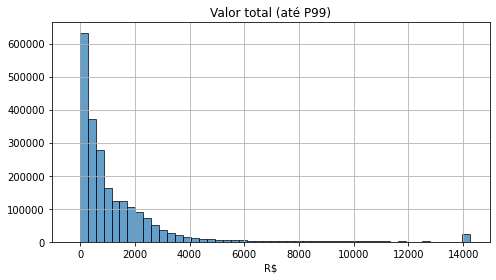

In [6]:
y = df['valor_total_num'].dropna()
y99 = y.clip(upper=y.quantile(0.99))
fig, ax = plt.subplots(figsize=(7, 4))
y99.hist(ax=ax, bins=50, edgecolor='black', alpha=0.7)
ax.set_title('Valor total (até P99)')
ax.set_xlabel('R$')
plt.tight_layout()
plt.show()


**Interpretação — histograma:** No eixo horizontal estão faixas de valor em R$; no vertical, a quantidade de registros em cada faixa. A forma mostra onde a maioria dos gastos se concentra e se há **assimetria** (cauda longa à direita). Valores acima do P99 foram cortados só na figura para não comprimir a parte central.

**Em termos de modelo:** A maior parte das despesas tende a ficar em faixas mais baixas; uma minoria puxa a média para cima. O **target não é simétrico** — na regressão pode fazer sentido **log** ou tratamento de cauda para o modelo não ser dominado por poucos valores muito altos.


#### Boxplot — Valor total

Mesma variável **sem** cortar outliers: mediana, quartis e pontos atípicos além dos bigodes.


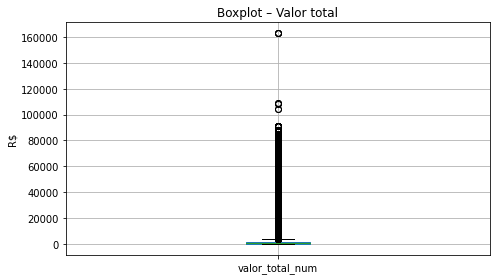

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='valor_total_num', ax=ax)
ax.set_title('Boxplot – Valor total')
ax.set_ylabel('R$')
plt.tight_layout()
plt.show()


**Interpretação — boxplot:** A caixa é o intervalo entre Q1 e Q3; a linha central é a **mediana**. Os bigodes vão até 1,5× a amplitude interquartílica; além deles aparecem **outliers**.

**Em termos de modelo:** A mediana indica o valor “típico”; muitos pontos acima do bigode indicam **gastos atípicos** (viagens caras ou lançamentos extremos). É preciso decidir se mantém, limita (cap) ou modela em **log(Valor total)** para reduzir o peso dos extremos.


#### Dispersão — Número diárias × Valor total

Cada ponto é um registro (amostra de até 50 mil). O eixo X fica entre −0,5 e 30 diárias para focar onde há massa.


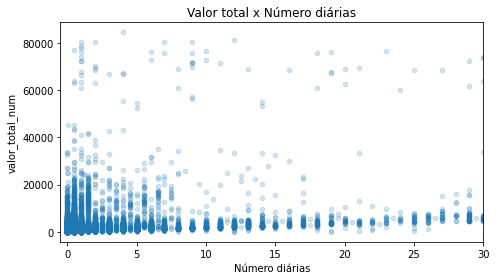

In [8]:
col_nd = col_num_diarias if col_num_diarias in df.columns else COLS_NUM[-1] if COLS_NUM else 'valor_total_num'
amostra = df[[col_nd, 'valor_total_num']].dropna().sample(n=min(50000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 4))
amostra.plot.scatter(x=col_nd, y='valor_total_num', alpha=0.2, ax=ax)
ax.set_xlim(-0.5, 30)
ax.set_title('Valor total x Número diárias')
plt.tight_layout()
plt.show()


**Interpretação — dispersão:** Tendência **positiva** indica que **Número diárias** é preditora relevante: em geral, mais diárias associam-se a maior gasto. A **largura da nuvem** mostra que o valor não depende só das diárias — **motivo, meio, órgão e destino** também importam.

**Em termos de modelo:** Só usar Número diárias deixa muita variância sem explicação; o modelo completo deve incluir outras *features*.


#### Gráficos complementares

Em seguida: **soma mensal** do Valor total, **mediana por Motivo** (12 categorias mais frequentes), **densidade** Valor diárias × Valor passagem (hexbin) e **duração × Valor total**. Cada figura vem com o seu texto de leitura.


##### Soma mensal do Valor total (milhões de R$)

Agregação por mês de **início da viagem** — tendência e sazonalidade grosseira.


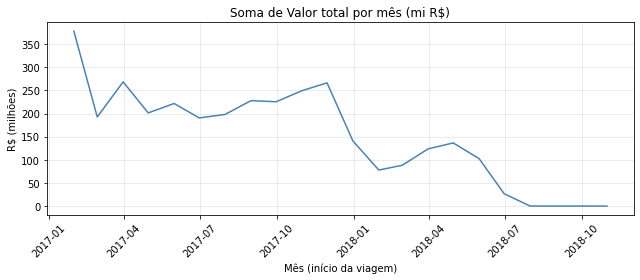

In [9]:
dt_col = next((c for c in df.columns if "início" in c.lower() and "viagem" in c.lower()), "Data início viagem")
mensal = (
    df.dropna(subset=[dt_col])
    .groupby(pd.Grouper(key=dt_col, freq="ME"), dropna=False)["valor_total_num"]
    .sum()
    / 1e6
)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mensal.index, mensal.values, color="steelblue")
ax.set_title("Soma de Valor total por mês (mi R$)")
ax.set_xlabel("Mês (início da viagem)")
ax.set_ylabel("R$ (milhões)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretação — série mensal:** Picos e quedas podem refletir calendário administrativo, conjuntura ou até **atraso na divulgação** de trechos (viagens sigilosas). Não interpretar só como “quantidade de viagens” sem cruzar com o que a seção 1 disse sobre **registro vs. pagamento**.


##### Mediana do Valor total por Motivo (12 mais frequentes)

Compara o gasto **típico** (mediana) entre os motivos mais comuns — robusto à cauda de valores altos.


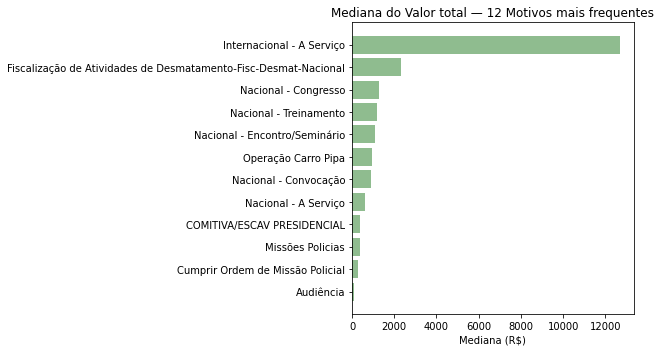

In [10]:
col_mot = acha_col(df, "Motivo")
if col_mot is None:
    col_mot = "Motivo"
top_motivos = df[col_mot].value_counts().head(12).index
sub_m = df[df[col_mot].isin(top_motivos)]
med_m = sub_m.groupby(col_mot, observed=False)["valor_total_num"].median().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(med_m.index.astype(str), med_m.values, color="darkseagreen")
ax.set_title("Mediana do Valor total — 12 Motivos mais frequentes")
ax.set_xlabel("Mediana (R$)")
plt.tight_layout()
plt.show()


**Interpretação — Motivo:** Medianas muito diferentes entre categorias sugerem que **Motivo** será preditora importante na regressão (além de Número diárias e duração).


##### Densidade — Valor diárias × Valor passagem (hexbin)

Amostra de até 80 mil registros; áreas mais escuras = mais pontos sobrepostos.


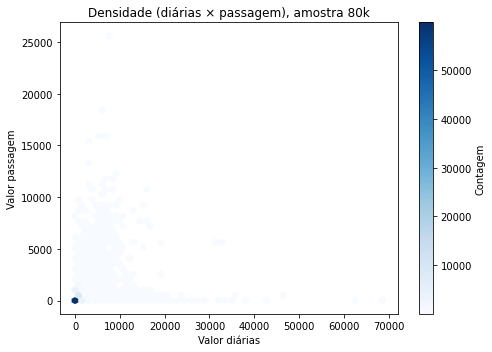

In [11]:
cols_hex = [c for c in [col_valor_diarias, col_valor_passagem] if c and c in df.columns]
if len(cols_hex) == 2:
    am_hex = df[cols_hex + ["valor_total_num"]].dropna().sample(n=min(80_000, len(df)), random_state=43)
    fig, ax = plt.subplots(figsize=(7, 5))
    hb = ax.hexbin(
        am_hex[cols_hex[0]],
        am_hex[cols_hex[1]],
        gridsize=45,
        cmap="Blues",
        mincnt=1,
        linewidths=0.1,
    )
    plt.colorbar(hb, ax=ax, label="Contagem")
    ax.set_xlabel(col_valor_diarias)
    ax.set_ylabel(col_valor_passagem)
    ax.set_title("Densidade (diárias × passagem), amostra 80k")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.text(0.5, 0.5, "Colunas de valor não encontradas", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


**Interpretação — hexbin:** Concentração forte perto de **passagem zero** é esperada (muitos registros só com diária). Onde há passagem paga, a nuvem desloca-se — mostra a **composição** do custo entre diárias e passagens.


##### Valor total × duração da viagem (dias)

Eixo X limitado ao P99 da duração para poucas viagens extremamente longas não dominarem o gráfico.


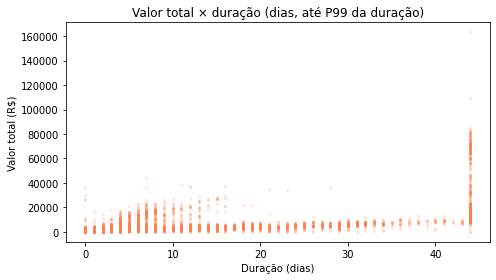

In [12]:
if "duracao_dias" in df.columns:
    am_d = df[["duracao_dias", "valor_total_num"]].dropna().sample(n=min(50_000, len(df)), random_state=44)
    cap_x = am_d["duracao_dias"].quantile(0.99)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(
        am_d["duracao_dias"].clip(upper=cap_x),
        am_d["valor_total_num"],
        alpha=0.15,
        s=4,
        c="coral",
    )
    ax.set_title("Valor total × duração (dias, até P99 da duração)")
    ax.set_xlabel("Duração (dias)")
    ax.set_ylabel("Valor total (R$)")
else:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.text(0.5, 0.5, "Coluna duracao_dias ausente (rode a célula de correlação/datas)", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


**Interpretação — duração:** Tendência positiva reforça que viagens **mais longas** costumam custar mais. O corte no P99 da duração só ajuda a ler a parte central; outliers de duração continuam existindo na base.


#### Heatmap — correlação de Pearson (numéricas)

Matriz entre variáveis numéricas principais (amostra 50k). O texto **“Como ler o heatmap”** vem logo após a figura.


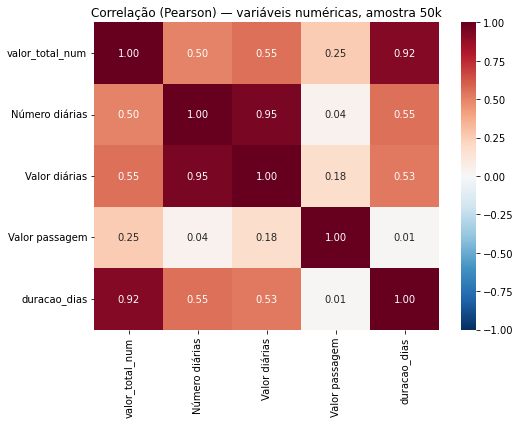

In [13]:
# Heatmap: Pearson entre numéricas (preditora vs. preditora e vs. alvo)
cols_hm = [
    c
    for c in [
        "valor_total_num",
        col_num_diarias,
        col_valor_diarias,
        col_valor_passagem,
        "duracao_dias",
    ]
    if c and c in df.columns
]
sam_hm = df[cols_hm].dropna().sample(n=min(50_000, len(df)), random_state=45)
cm = sam_hm.corr(numeric_only=True)
fig3, ax_hm = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax_hm)
ax_hm.set_title("Correlação (Pearson) — variáveis numéricas, amostra 50k")
plt.tight_layout()
plt.show()


### Como ler o heatmap de correlação

Cada número na matriz é a **correlação linear de Pearson** entre duas variáveis (escala de −1 a +1). A **diagonal** vale sempre 1,00 (cada coluna com ela mesma). A tabela é **simétrica**: o coeficiente entre A e B é o mesmo entre B e A.

**Cores (mapa `RdBu_r`, centrado em zero):** tons mais **vermelhos** indicam correlação **positiva** (tendência a subir junto, no sentido linear); tons mais **azuis**, correlação **negativa**. Quanto mais **próximo de 0**, mais fraca é a associação **linear** entre aquelas duas colunas — isso **não** quer dizer que não exista relação nenhuma (pode ser não linear, ou mistura de tipos de viagem dentro da mesma coluna).

**`valor_total_num` (alvo) no heatmap:** no notebook o **Valor total** tratado como número fica na coluna **`valor_total_num`**. No gráfico, localize essa etiqueta na **linha** e na **coluna**: cada célula fora da diagonal na interseção com outra variável é a correlação de Pearson **entre o alvo e essa preditora** — o mesmo tipo de informação da seção **3.1.2**, só que aqui você vê todas de uma vez (e ainda vê a diagonal 1,00 do alvo com ele mesmo). Na prática, a “faixa” da linha ou coluna de **`valor_total_num`** resume o que interessa para regressão contra o total.

**Preditora vs. preditora:** o restante da matriz (cruzamentos que **não** envolvem `valor_total_num`) mostra se duas preditoras numéricas sobem ou descem juntas — útil para notar **multicolinearidade** (ex.: valor de diárias e número de diárias).

**Comparar com 3.1.2:** os coeficientes do alvo contra cada coluna devem ser **coerentes** com a tabela de correlação com **valor_total_num** que você já imprimiu; se algo divergir muito, confira se rodou as células na mesma ordem e com o mesmo `df`.

**Cuidados:** Pearson **não** é causalidade; outliers e **muitos zeros** (caso da passagem) distorcem a correlação linear. Por isso usamos **amostra** com seed fixo, igual espírito da análise anterior — e o texto sobre **Valor passagem** no complemento continua valendo para não interpretar esse quadrado isolado como “passagem típica” no dia a dia.


As variáveis Número diárias e Valor diárias possuem alta correlação sendo necessário remover a variável Valor diárias para evitar a multicolinearidade no modelo de regressão.
A variável duracao_dias tem alta correlação com a variável target Valor total, o que pode indicar uma excelente variável preditora para o modelo.


## 4. Discussão Preliminar

Com base nas seções 3.1 (incluindo **3.1.1** valores ausentes e **3.1.2** correlação) e **3.2**, destaque:

**Padrões e relações:** A variável **Valor total** costuma apresentar **forte assimetria positiva** (média bem acima da mediana) e alto **CV%**, com outliers visíveis no boxplot. O gráfico **Número diárias × Valor total** tende a mostrar **relação positiva**, mas com muita variabilidade, sugerindo que Motivo, Meio de transporte e órgão serão importantes. **Valor passagem** é zero em muitos registros (apenas diária); quando há passagem, os valores podem ser elevados.

**Qualidade dos dados:** Cargo tem elevada proporção de nulos; **Município/UF** e **Categoria passagem** têm muitos nulos quando não há trecho de passagem. Colunas monetárias e Número diárias exigem conversão de vírgula para ponto (feita na carga); datas devem ser convertidas para datetime para derivar duração e mês/ano. Duplicatas foram removidas.

**Enquadramento e timing administrativo (seção 1):** Os valores são **indenizações** por viagem a serviço (Lei 8.112/1990), registrados como **lançamentos** no ecossistema SCDP/dados abertos. A **data de início** da viagem **não** coincide necessariamente com o **pagamento** de diárias ou com o **registro da emissão** de passagens; viagens **sigilosas** podem entrar tarde em bases públicas. Por isso, agregações por período e o uso de datas como preditoras pedem **interpretação prudente** (o modelo vê o que está na tabela, não o fluxo administrativo completo).

**Implicações para a modelagem:** Considerar transformação no target (ex.: log(1+y)); encoding para Motivo e Meio de transporte; agrupamento de categorias raras; decisão sobre subconjunto (todos vs. só com passagem) e validação temporal (treino/teste por período).

---

## 5. Próximos Passos

**Ajustes nos dados:** Garantir datas em datetime e criar duração da viagem, mês e ano; tratar nulos em Cargo, Município/UF e Categoria passagem; agrupar categorias raras em Motivo e Meio de transporte; avaliar transformação no target (log) ou tratamento de outliers.

**Variáveis:** Alvo = **Valor total** (regressão). Preditoras candidatas: Número diárias, duração, mês, ano, Motivo, Meio de transporte, órgão (codificado/agrupado). Evitar Nome servidor (muitas categorias).

**Encoding:** Na regressão linear, usar **one-hot com `drop_first`** nas categóricas de **baixa cardinalidade**; para nomes de órgão, UG, município ou servidor, **não** usar one-hot direto — preferir agregação, nível hierárquico (ex.: só órgão superior) ou algoritmos que suportem muitas categorias com regularização.

**Modelagem:** Split treino/validação/teste (considerar hold-out temporal). Modelos: regressão linear (baseline), árvore, random forest, gradient boosting. Métricas: RMSE, MAE, R² (e eventualmente MAPE). Pipeline com encoding e escalonamento conforme o algoritmo.

---

## Referências

- **Viagens a serviço do governo federal (SCDP)** — Dados abertos: [dados.gov.br – conjunto SCDP](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp).
- **Sistema SCDP:** [novoscdp – home](https://www2.scdp.gov.br/novoscdp/home.xhtml).
- **Portal da Transparência — Viagens a Serviço:** [visão geral](https://portaldatransparencia.gov.br/viagens/visao-geral).